<a href="https://colab.research.google.com/github/sophiebunn/CUDA-audio-equalizer/blob/main/audio-equalizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# set up cuda
!pip install nvcc4jupyter
!pip install scikit-cuda
!pip install numpy
!pip install pycuda
!pip install matplotlib
!pip install scipy
%load_ext nvcc4jupyter

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.7 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=5ad908dab528ef6090600f73ac8ea3de8a37b44c519b249eb4b91a5603670d8c
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda
Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpfm8bo1po".


In [ ]:
import torch # torch and device before pycuda.autoinit to avoid context conflicts
device = torch.device('cuda')
torch.zeros(1).to(device)

import pycuda.autoinit
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pycuda.gpuarray as gpuarray
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import numpy as np

In [ ]:
# CUDA code as python string for PyCUDA
mod = SourceModule(
    """
    #include <stdio.h>

  __global__ void frequency_gain(float2* __restrict__ freqs, const int bins, const float bass_gain, const float mid_gain, const float treble_gain, const int bass_max, const int mid_max, const int treble_max) {

      for (int idx = blockIdx.x * blockDim.x + threadIdx.x; idx < bins; idx += blockDim.x * gridDim.x) {
        float gain = 1.0f;

        // frequencies greater than treble cannot be heard, ignore
        if (idx < bass_max) {
            gain = bass_gain;
        }
        else if (idx < mid_max) {
            gain = mid_gain;
        }
        else if (idx < treble_max) {
            gain = treble_gain;
        }

        freqs[idx].x *= gain;
        freqs[idx].y *= gain;
      }

  }
  """
)

In [ ]:
# audio loading
freq_gain_kernel = mod.get_function("frequency_gain")

sample_rate, stereo_audio = wavfile.read("file_example_WAV_1MG.wav")

# set up mono audio with max bounds -1.0 to 1.0
mono_audio = np.mean(stereo_audio, axis=1).astype('float32')
mono_audio /= 32768.0 # max float size
mono_tensor = torch.from_numpy(mono_audio).to(device)

/tmp/ipykernel_5674/2780863478.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, stereo_audio = wavfile.read("file_example_WAV_1MG.wav")


In [ ]:
# one dimensional Fourier transform
fft_output = torch.fft.rfft(mono_tensor)
fft_output = fft_output.cpu().numpy()
n_bins = len(fft_output)
gpu_fft_output = gpuarray.to_gpu(fft_output)

# get frequency bins
freqs = np.fft.rfftfreq(len(mono_audio), d=1/sample_rate)

bass_max = np.searchsorted(freqs, 300)
mid_max = np.searchsorted(freqs, 4000)
treble_max = np.searchsorted(freqs, 20000)

# set and apply gains
bass_gain = 5.0
mid_gain = 1.0
treble_gain = 0.25

freq_gain_kernel(
    gpu_fft_output,
    np.int32(n_bins),
    np.float32(bass_gain),
    np.float32(mid_gain),
    np.float32(treble_gain),
    np.int32(bass_max),
    np.int32(mid_max),
    np.int32(treble_max),
    block=(256, 1, 1),
    grid=((n_bins + 255) // 256, 1)
)


In [ ]:
# get gain-applied output
output = gpu_fft_output.get()
output_tensor = torch.from_numpy(output).to(device)
irfft_output = torch.fft.irfft(output_tensor, mono_audio.size)
processed_audio = (irfft_output.cpu().detach().numpy() * 32768.0).astype('int16')

wavfile.write("output.wav", data=processed_audio, rate=sample_rate)

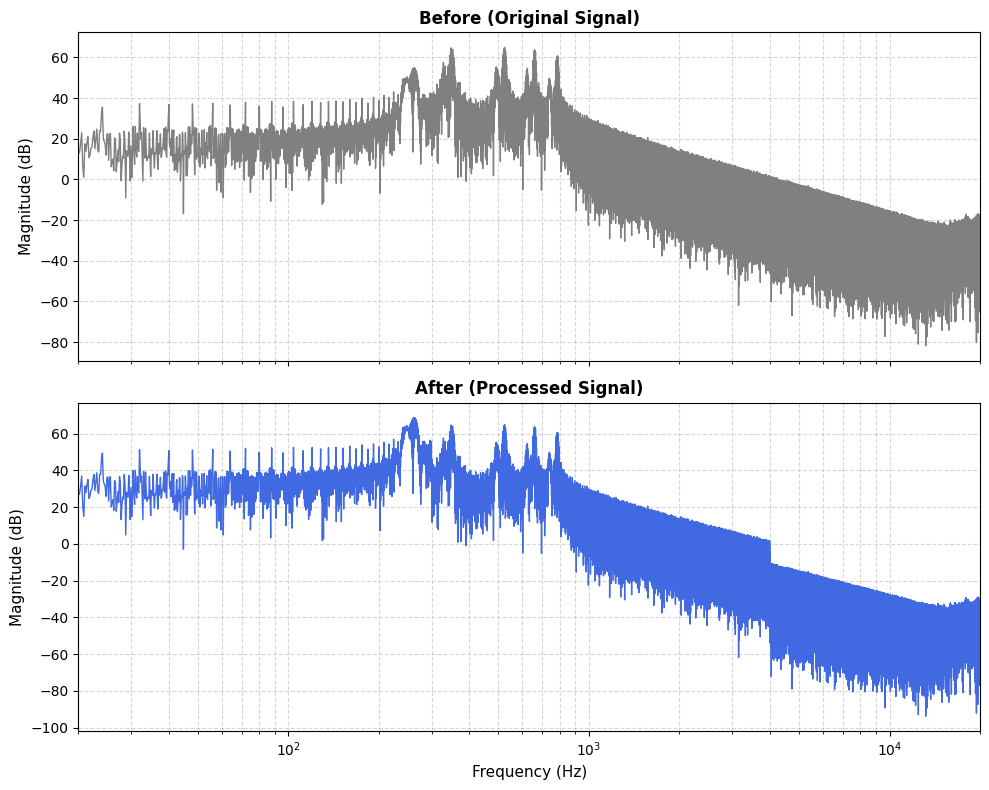

In [ ]:
# plotting before and after differences in db
db_before = 20 * np.log10(np.abs(fft_output))
db_after = 20 * np.log10(np.abs(output))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(freqs, db_before, color='gray', linewidth=1, label='Before Gain')
ax1.set_title("Before (Original Signal)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Magnitude (dB)", fontsize=11)
ax1.grid(True, which="both", linestyle="--", alpha=0.5)

ax2.plot(freqs, db_after, color='royalblue', linewidth=1, label='After Gain')
ax2.set_title("After (Processed Signal)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Frequency (Hz)", fontsize=11)
ax2.set_ylabel("Magnitude (dB)", fontsize=11)
ax2.grid(True, which="both", linestyle="--", alpha=0.5)

for ax in [ax1, ax2]:
    ax.set_xlim(20, 20000)
    ax.set_xscale('log')

plt.tight_layout()
plt.savefig('signal_compare.png')
plt.show()